## Imports das Bibliotecas

In [1]:
## Imports Geral
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import nltk
import numpy as np 

# Import para Visualização de Dados
from wordcloud import WordCloud

# Extração de Texto
from nltk.corpus import stopwords

# Importações de Metrica
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Preprocessamento
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# Modelos
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

import warnings

# Suprimir todos os warnings
warnings.filterwarnings("ignore")

# DESENVOLVER O MODELO SEM VIES 

# Analise dos dados

In [2]:
df = pd.read_csv("cor_da_justica.csv")
remover_colunas = ["Unnamed: 0", "uris.uriAutores", "uris.uriPropPrincipal",
                   "uris.uriUltimoRelator", "foto", "cpf", ]
df = df.drop(columns=remover_colunas)
df = df.dropna(subset=["ementa"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11432 entries, 0 to 11736
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   ementa                 11432 non-null  object
 1   ementaDetalhada        491 non-null    object
 2   ano                    11432 non-null  int64 
 3   keywords               5072 non-null   object
 4   nome                   11432 non-null  object
 5   sexo                   11432 non-null  object
 6   nascimento             11432 non-null  object
 7   local_nascimento       11432 non-null  object
 8   escolaridade           11170 non-null  object
 9   uris.uriPartido        11432 non-null  object
 10  ementa_principal       11432 non-null  object
 11  situacao               2068 non-null   object
 12  tipo                   2242 non-null   object
 13  keywords_principal     2219 non-null   object
 14  nome_partido           11432 non-null  object
 15  sigla_partido          1

In [3]:
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["ementaDetalhada"] if x["ementaDetalhada"] == str(x["ementaDetalhada"]) else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["ementa_principal"] if x["ementa_principal"] != str("vazio") else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["keywords"] if x["keywords"] == str(x["keywords"]) else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["keywords_principal"] if x["keywords_principal"] == str(x["keywords_principal"]) else x["ementa"] , axis=1)

In [4]:
df = df.drop(columns=["ementaDetalhada", "ementa_principal", 'keywords', 'keywords_principal'])

In [5]:
df["situacao"].loc[(df["situacao"] == "Aguardando Designação de Relator(a)" ) | (df["situacao"] == "Aguardando Parecer") | (df["situacao"] == "Aguardando Encaminhamento") | (df["situacao"] == "Aguardando Definição Encaminhamento") | (df["situacao"] == "Aguardando Recurso") | (df["situacao"] == "Aguardando Despacho de Arquivamento ") | (df["situacao"] == "Aguardando Deliberação")  | (df["situacao"] == "Aguardando Designação - Aguardando Devolução de Relator(a) que deixou de ser Membro") | (df["situacao"] == "Aguardando Análise de Parecer") | (df["situacao"] == "Arquivada") ] = "AGUARDANDO"
df["situacao"].loc[(df["situacao"] == "Tramitando em Conjunto" ) | (df["situacao"] == "Pronta para Pauta")] = "TRAMITANDO"
df["situacao"] = df["situacao"].fillna("RECUSADO")

In [6]:
df = df.drop(df[(df['cor'] == "#NE") | (
    df["cor"] == "#NE#") | (df["cor"] == "NÃO DIVULGÁVEL")].index).reset_index(drop=True)

df["cor"].loc[(df["cor"] == "AMARELA") | (df["cor"] == "INDÍGENA") | (df["cor"] == "PARDA") | (df["cor"] == "PRETA")] = "OUTROS"

In [7]:
df['cor'].value_counts()

cor
BRANCA    3711
OUTROS    1532
Name: count, dtype: int64

In [11]:
# # y_pred = model_LR.predict(X)
# # rng = np.random.default_rng(42)
# rng = np.random.default_rng(62)
# numbers = rng.random(len(df))
# balanceamento = [df.loc[df["cor"] == "BRANCA"].sample(1)  if i < prob_brancos else df.loc[df['cor'] == 'OUTROS'].sample(1) for i in numbers]
# df = pd.concat(balanceamento)


In [13]:
# df["nome"].value_counts().unique()
df["ementa"].count()

5243

In [15]:
cor = df["cor"].value_counts().reset_index()
cor["cor"].unique()
cor

,cor,count
0,BRANCA,3690
1,OUTROS,1553


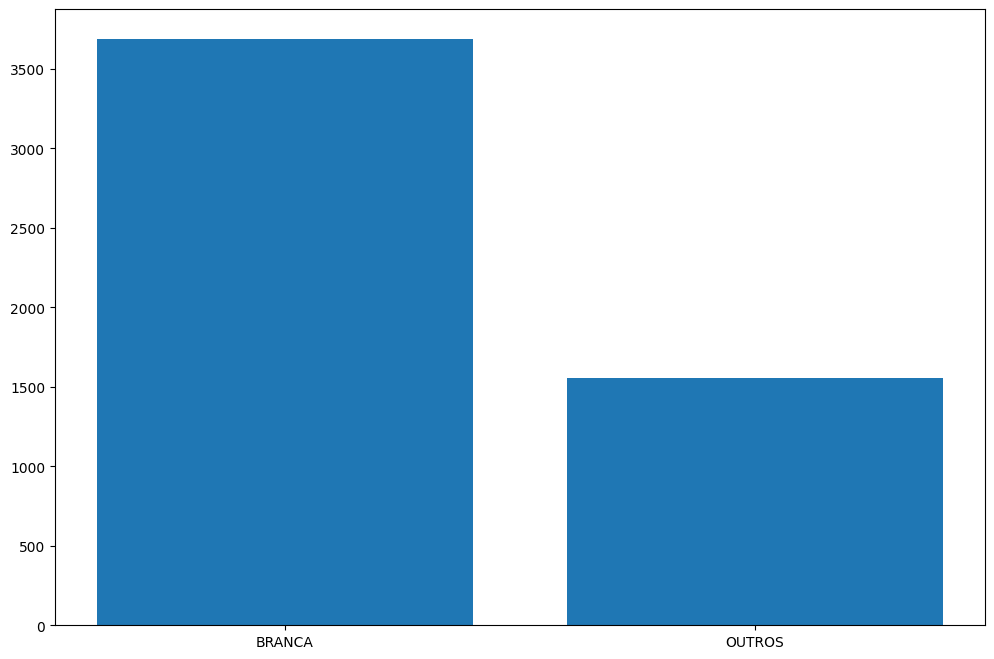

In [16]:
fx, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.bar(cor["cor"], height=cor["count"])
plt.show()

In [17]:
df["ementa"].dropna().count()

5243

## Bag Of Words

In [18]:
# nltk.download('stopwords')

In [19]:
df = df.dropna(subset=["ementa"]).reset_index(drop=True)

In [20]:
tf_idf = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
X = tf_idf.fit_transform(df["ementa"])
vocab = tf_idf.get_feature_names_out()
vocab = ' '.join(vocab)


## WORD CLOUD

In [21]:
le = LabelEncoder()

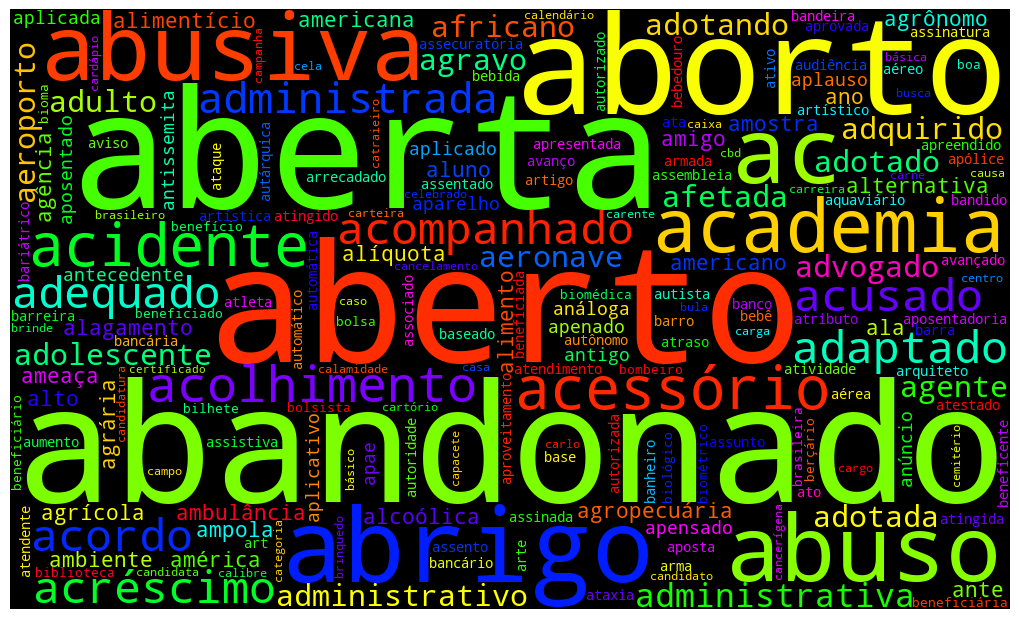

In [22]:
# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='black',
    colormap='gist_rainbow',
    min_font_size=10).generate(vocab)

plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

In [23]:
df_brancos = df[df["cor"] == "BRANCA"]
df_outros  = df[df["cor"] == "OUTROS"]




tf_idf_brancos = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
tf_idf_outros = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )


y_brancos = le.fit_transform(df_brancos["situacao"])
y_outros = le.fit_transform(df_outros["situacao"])


In [24]:
X_brancos = tf_idf_brancos.fit_transform(df_brancos["ementa"])
vocab_brancos = tf_idf_brancos.get_feature_names_out()
vocab_brancos = ' '.join(vocab_brancos)


In [25]:
X_outros = tf_idf.fit_transform(df_outros["ementa"])
vocab_outros = tf_idf.get_feature_names_out()
vocab_outros = ' '.join(vocab_outros)


## GRUPO 1: PESSOA DE COR DE PELE BRANCA

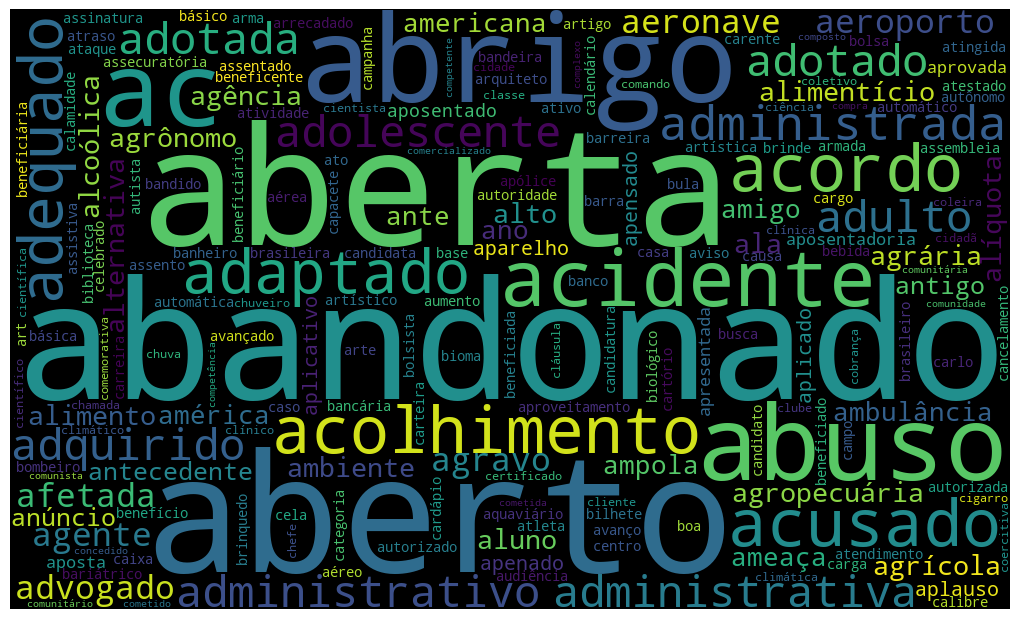

In [26]:

# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='black',
    min_font_size=10).generate(vocab_brancos)
plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

## GRUPO 2: PESSOA DE COR DE PELE DIFERENTES 

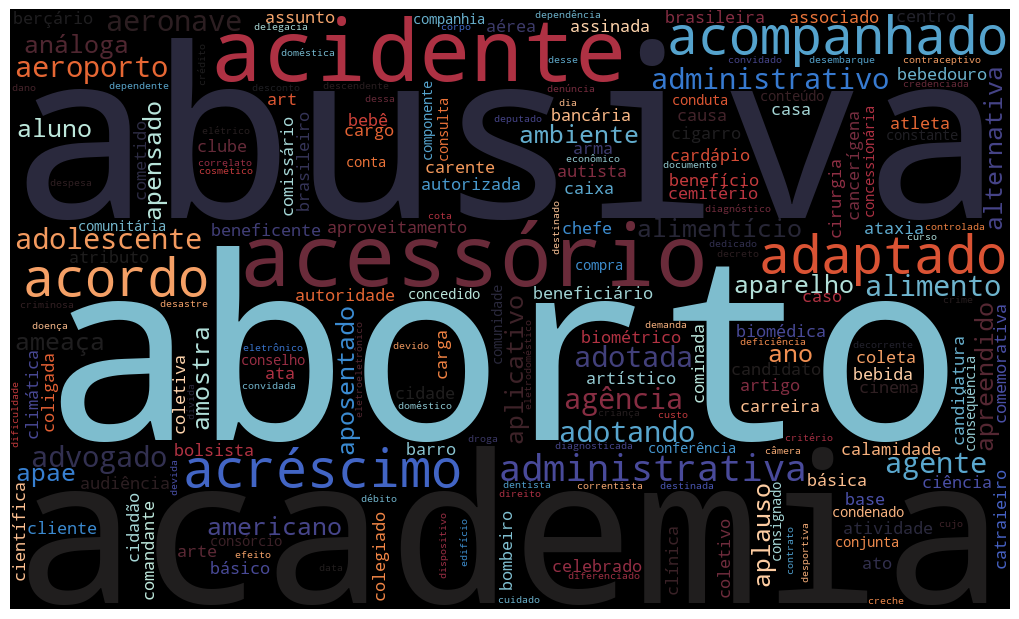

In [27]:

# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='black',
    colormap='icefire',
    min_font_size=10).generate(vocab_outros)
plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

# PCA

In [28]:
df['cor']

0       BRANCA
1       OUTROS
2       OUTROS
3       BRANCA
4       BRANCA
         ...  
5238    OUTROS
5239    BRANCA
5240    BRANCA
5241    OUTROS
5242    BRANCA
Name: cor, Length: 5243, dtype: object

In [29]:
le = LabelEncoder()

df["cor"] = le.fit_transform(df["cor"])
y = df["cor"]

In [30]:
y

0       0
1       1
2       1
3       0
4       0
       ..
5238    1
5239    0
5240    0
5241    1
5242    0
Name: cor, Length: 5243, dtype: int32

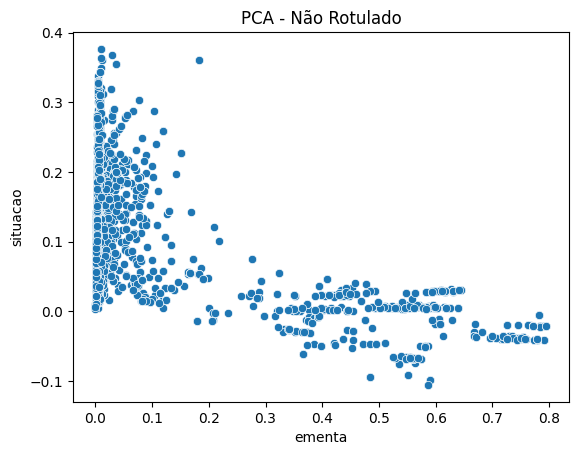

In [31]:
pca = TruncatedSVD(n_components=2)
X_pca = pca.fit_transform(X)
df_pca = pd.DataFrame(data=X_pca, columns=['ementa', 'situacao'])
df_pca["target"] = df["cor"].reset_index(drop=True)


sns.scatterplot(x='ementa', y="situacao", data=df_pca)
plt.title('PCA - Não Rotulado')
plt.show()

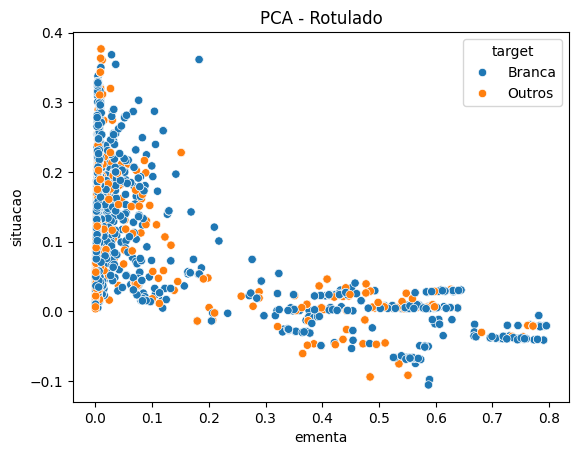

In [32]:
y_map = {0: 'Branca', 1: 'Outros'}

df_pca["target"] = df["cor"].map(y_map)

sns.scatterplot(x='ementa', y="situacao", hue="target", data=df_pca)
plt.title('PCA - Rotulado')
plt.show()

## Treino do Modelo

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
from imblearn.over_sampling import SMOTE

# transform the dataset
oversample = SMOTE()
X_train, y_train = oversample.fit_resample(X_train, y_train)

In [35]:
## Funçao para Avaliação dos Modelos

def evaluation_parametrics(name, y_test, y_pred):
    cm_test = confusion_matrix(y_test, y_pred)
    
    t1 = ConfusionMatrixDisplay(cm_test, display_labels=[
                                "Branca", 'Outros'])
    print("Classification Report for Data Test")
    print(classification_report(y_test, y_pred))
    t1.plot()

In [36]:
#K Fold

K = 5
kf = KFold(n_splits=K, shuffle=False) 

# Logistic Regression

In [37]:
model_LR = LogisticRegression(random_state=42, max_iter=1000, solver="liblinear", penalty="l2", C=3, tol=0.001)
cross_val_results = cross_val_score(model_LR, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_LR, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)


print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.73735036 0.77462587 0.74804883 0.75027132 0.73573216]
Media da Accuracy:  0.8186142382057794
Media da MACRO F1:  0.7492057068097587
Desvio Padrão da MACRO F1:  0.013933731838514367


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       739
           1       0.70      0.69      0.70       310

    accuracy                           0.82      1049
   macro avg       0.78      0.78      0.78      1049
weighted avg       0.82      0.82      0.82      1049



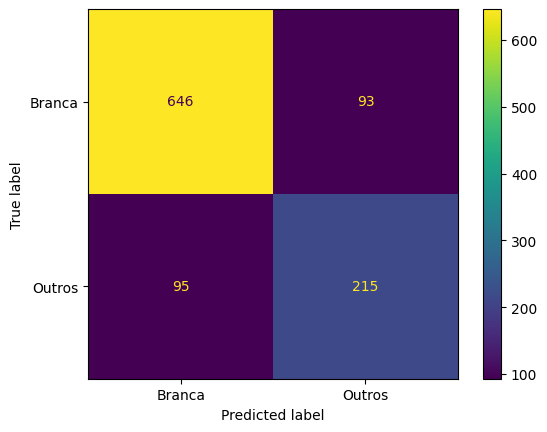

In [39]:
model_LR.fit(X_train, y_train)
y_pred = model_LR.predict(X_test)
evaluation_parametrics("Machine Learning - Logistic", y_test, y_pred)

# SGD Classifier

In [40]:
model_SGD = SGDClassifier(random_state=42, loss="squared_hinge", alpha=0.0001, learning_rate="constant", eta0=0.1, power_t=0.5, penalty="l2", tol=0.001, early_stopping=True, n_jobs=-1, class_weight="balanced")
cross_val_results = cross_val_score(model_SGD, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_SGD, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.81461596 0.81206567 0.81013084 0.79354767 0.78294502]
Media da Accuracy:  0.8319624651612951
Media da MACRO F1:  0.8026610317540157
Desvio Padrão da MACRO F1:  0.012320225440608163


# K Neighbors Classifier

In [43]:
model_KNeighbors = KNeighborsClassifier(n_neighbors=5, weights="distance", algorithm="auto", leaf_size=50, p=2 )
cross_val_results = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="f1_macro", )
cross_val_results_accuracy = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.83160534 0.82730477 0.83645419 0.8312027  0.81966852]
Media da Accuracy:  0.8598126896571798
Media da MACRO F1:  0.829247104342994
Desvio Padrão da MACRO F1:  0.005600885896395742


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.95      0.70      0.81       739
           1       0.56      0.90      0.69       310

    accuracy                           0.76      1049
   macro avg       0.75      0.80      0.75      1049
weighted avg       0.83      0.76      0.77      1049



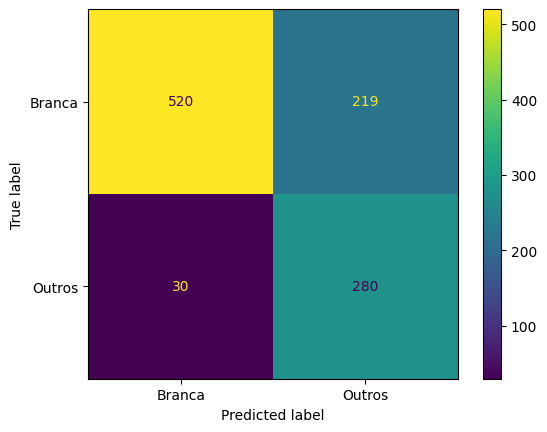

In [44]:
model_KNeighbors.fit(X_train, y_train)
y_pred = model_KNeighbors.predict(X_test)
evaluation_parametrics("Machine Learning - K Neighbors", y_test, y_pred)

# SVM (SUPPORT VECTOR MACHINE)

In [46]:
model_SVM = LinearSVC(random_state=42, loss='squared_hinge', max_iter=1000, penalty="l2", C=3, tol=0.0001, multi_class='ovr', dual=True, class_weight="balanced",  )
cross_val_results = cross_val_score(model_SVM, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_SVM, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.83338204 0.83184766 0.81979118 0.81426308 0.81221042]
Media da Accuracy:  0.8493206907341779
Media da MACRO F1:  0.8222988766912052
Desvio Padrão da MACRO F1:  0.008793809016479057


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       739
           1       0.71      0.71      0.71       310

    accuracy                           0.83      1049
   macro avg       0.79      0.79      0.79      1049
weighted avg       0.83      0.83      0.83      1049



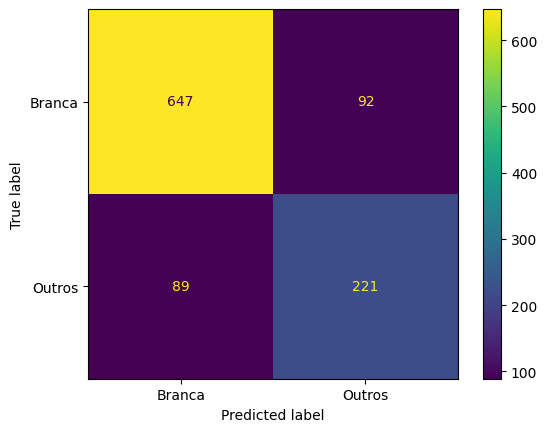

In [47]:
model_SVM.fit(X_train, y_train)
y_pred = model_SVM.predict(X_test)
evaluation_parametrics("Machine Learning - SVM", y_test, y_pred)

# Random Forest

In [49]:
model_Random_Forest = RandomForestClassifier(random_state=42, n_estimators=500, criterion="gini", max_features='sqrt', class_weight='balanced', n_jobs=-1, )
cross_val_results = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="accuracy")


print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.85871726 0.86655763 0.8444588  0.84265052 0.82352597]
Media da Accuracy:  0.8809809778851541
Media da MACRO F1:  0.8471820344388858
Desvio Padrão da MACRO F1:  0.014805642853786312


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       739
           1       0.84      0.68      0.75       310

    accuracy                           0.87      1049
   macro avg       0.86      0.81      0.83      1049
weighted avg       0.87      0.87      0.86      1049



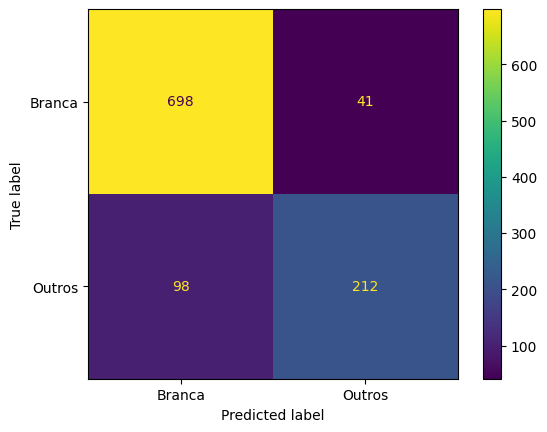

In [50]:
model_Random_Forest.fit(X_train, y_train)
y_pred = model_Random_Forest.predict(X_test)
evaluation_parametrics("Machine Learning - Random Forest", y_test, y_pred)

# Decision Tree

In [52]:
model_Decision_Tree = DecisionTreeClassifier(random_state=42, criterion="entropy", splitter="random", class_weight="balanced", ccp_alpha=0.0001)

cross_val_results = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.82620662 0.8308768  0.81551024 0.83198315 0.80404128]
Media da Accuracy:  0.8487505366797896
Media da MACRO F1:  0.8217236188902761
Desvio Padrão da MACRO F1:  0.010586854155690932


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       739
           1       0.71      0.71      0.71       310

    accuracy                           0.83      1049
   macro avg       0.79      0.79      0.79      1049
weighted avg       0.83      0.83      0.83      1049



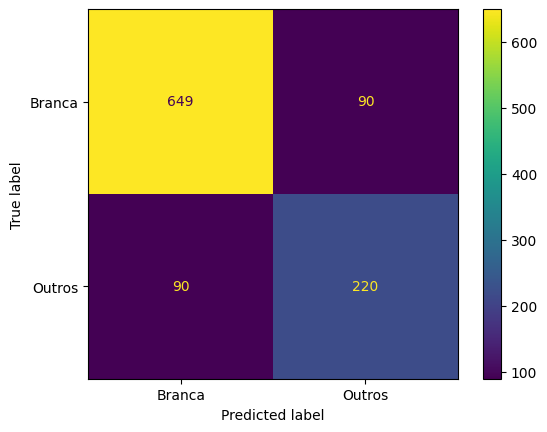

In [53]:
model_Decision_Tree.fit(X_train, y_train)
y_pred = model_Decision_Tree.predict(X_test)
evaluation_parametrics("Machine Learning - Decision Tree", y_test, y_pred)

In [55]:
#Classificar aleatorio

#30% de Outros 
#70% Brancos

# Se numero aleátorio for maior que 0.2975 Brancos, 
#menor outros

#Outros/Total
#1581/5292

# Resultado
#.29875


